In [1]:
# General imports
import numpy as np
np.random.seed(42)
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib notebook
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import os
import yaml
import importlib.util
from resum.multi_fidelity_gaussian_process import GPMultiFidelityVisualizer
from resum.multi_fidelity_gaussian_process import MFGPModel

In [2]:
path_to_settings = ".."
with open(f"{path_to_settings}/settings.yaml", "r") as f:
    config_file = yaml.safe_load(f)

version       = config_file["path_settings"]["version"]
path_out_cnp  = config_file["path_settings"]["path_out_cnp"]
path_out_resum = config_file["path_settings"]["path_out_resum"]
prefix = f'{path_out_resum}/{version}'
file_in=f'{path_out_cnp}/{version}/cnp_{version}_output.csv'

In [3]:

if not os.path.exists(prefix):
   os.makedirs(prefix)

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels        = config_file["simulation_settings"]["theta_headers"]
y_label_cnp     = 'y_cnp'
y_err_label_cnp = 'y_cnp_err'
y_label_sim     = 'y_raw'

y_scaling = config_file["simulation_settings"]["y_scaling"]
y_scaling = 1.
# Set parameter boundaries
xmin = config_file["simulation_settings"]["theta_min"]
xmax = config_file["simulation_settings"]["theta_max"]

parameters={}
for i,x in enumerate(x_labels):
   parameters[x]=[xmin[i],xmax[i]]

# Assign costs
low_fidelity_cost = config_file["simulation_settings"]["lf_cost"]
high_fidelity_cost = config_file["simulation_settings"]["lf_cost"]

In [4]:
y_label_lf = y_label_cnp
y_label_mf = y_label_cnp
y_label_hf = y_label_sim

In [5]:
data=pd.read_csv(file_in)
data = data.drop_duplicates()

In [6]:

LF_cnp_noise=np.mean(data.loc[(data['fidelity']==0.) & (data['iteration']==0)][y_err_label_cnp].to_numpy())
HF_cnp_noise=np.mean(data.loc[(data['fidelity']==1.) & (data['iteration']==0)][y_err_label_cnp].to_numpy())
HF_sim_noise=np.var(y_scaling*data.loc[(data['fidelity']==1.) & (data['iteration']==0)][y_label_sim].to_numpy())

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['fidelity'] == 1].tolist()
row_l=data.index[data['fidelity'] == 0].tolist()

x_train_hf = data.loc[(data['fidelity']==1.) & (data['iteration']==0)][x_labels].to_numpy().tolist()
y_train_hf = (y_scaling*data.loc[(data['fidelity']==1.) & (data['iteration']==0)][y_label_hf].to_numpy()).tolist()

x_train_mf = data.loc[(data['fidelity']==1.) & (data['iteration']==0)][x_labels].to_numpy().tolist()
y_train_mf = data.loc[(data['fidelity']==1.) & (data['iteration']==0)][y_label_mf].to_numpy().tolist()

x_train_lf = data.loc[(data['fidelity']==0.) & (data['iteration']==0)][x_labels].to_numpy().tolist()
y_train_lf = data.loc[(data['fidelity']==0.) & (data['iteration']==0)][y_label_lf].to_numpy().tolist()


In [7]:
def get_combined_variance(mu, sigma):
    mu_err=np.sum(1000.*(mu-np.ones(mu.shape[0])*mu.mean())**2)
    var_comb = (np.sum((1000.-1.)*sigma**2)+mu_err)/(1000.**2-1.)
    return var_comb

In [8]:
LF_cnp_noise= get_combined_variance(data.loc[(data['fidelity']==0.) & (data['iteration']==0)][y_label_cnp].to_numpy(),data.loc[(data['fidelity']==0.) & (data['iteration']==0)][y_err_label_cnp].to_numpy())

In [9]:
noise_lf = LF_cnp_noise
noise_mf = HF_cnp_noise
noise_hf = HF_sim_noise

In [10]:
trainings_data = {"lf": [x_train_lf,y_train_lf], "hf": [x_train_hf,y_train_hf]}
noise = {"lf": noise_lf, "hf": noise_hf}

In [11]:
#trainings_data = {"lf": [x_train_lf,y_train_lf], "mf": [x_train_mf,y_train_mf], "hf": [x_train_hf,y_train_hf]}
#noise = {"lf": noise_lf, "mf": noise_mf, "hf": noise_hf}

In [12]:

# Path to the inequalities.py file
file_path = f"{path_to_settings}/inequalities.py"

if os.path.exists(file_path):
    spec = importlib.util.spec_from_file_location("inequalities", file_path)
    inequalities_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(inequalities_module)
    InequalityConstraints = inequalities_module.InequalityConstraints
    inequalities = InequalityConstraints()
    print("InequalityConstraints loaded successfully.")
else:
    inequalities = None

In [13]:
mf_model = MFGPModel(trainings_data, noise, normalize=True, inequality_constraints=inequalities)


In [14]:
mf_model.build_model(10)

Optimization restart 1/10, f = 371.7586824174583
Optimization restart 2/10, f = 371.7586824020691
Optimization restart 3/10, f = 371.75868342954516
Optimization restart 4/10, f = 371.7586824069407
Optimization restart 5/10, f = 371.75868240421414
Optimization restart 6/10, f = 371.75868239946715
Optimization restart 7/10, f = 371.75868282046724
Optimization restart 8/10, f = 371.75868245524305
Optimization restart 9/10, f = 371.7586825884042
Optimization restart 10/10, f = 371.75868249611415


In [15]:
mf_model.model.gpy_model

gp.,value,constraints,priors
multifidelity.RBF_rho_0.variance,1.1783742489903943,+ve,
multifidelity.RBF_rho_0.lengthscale,-1.1761110507870893,,
multifidelity.RBF_delta_0.variance,3.415228894416361,+ve,
multifidelity.RBF_delta_0.lengthscale,3.5046878043255374,+ve,
multifidelity.scale,0.20860301376248885,,
mixed_noise.Gaussian_noise.variance,0.0422534611310566,+ve fixed,
mixed_noise.Gaussian_noise_1.variance,0.0023452036865445175,+ve fixed,


In [16]:
%%capture
leg_label = []
ncol=3
nrow=int(np.ceil(len(x_labels)/ncol))
fig4,_  = plt.subplots(int(np.ceil(len(x_labels)/1)), 1, figsize=(5, 12), constrained_layout=True)



In [17]:
mf_vis = GPMultiFidelityVisualizer(mf_model,list(trainings_data.keys()),parameters)

In [18]:

sample=0
active_learning = False
add_new_sample=True

while ( sample <= data['iteration'].max()):
    print('Sample #', sample)
    if sample > 0:    
        x_train_hf_sim = data[(data['fidelity']==1.) & (data['iteration']==sample)][x_labels].to_numpy().tolist()
        y_train_hf_sim = data[(data['fidelity']==1.) & (data['iteration']==sample)][y_label_sim].to_numpy().tolist()
        print(f"Adding {x_train_hf_sim}")   
        x_train_hf_cnp = data[(data['fidelity']==1.) & (data['iteration']==sample)][x_labels].to_numpy().tolist()
        y_train_hf_cnp = data[(data['fidelity']==1.) & (data['iteration']==sample)][y_label_cnp].to_numpy().tolist()

        x_train_lf_cnp = data[(data['fidelity']==0.) & (data['iteration']==sample)][x_labels].to_numpy().tolist()
        y_train_lf_cnp = data[(data['fidelity']==0.) & (data['iteration']==sample)][ y_label_cnp].to_numpy().tolist()
        trainings_data_new = {"lf": [x_train_lf_cnp,y_train_lf_cnp], "mf": [x_train_hf_cnp,y_train_hf_cnp], "hf": [x_train_hf_sim,y_train_hf_sim]}
        mf_model.set_data(trainings_data_new)

    # find the next data point
    if sample == data['iteration'].max() and active_learning==True:
        x_next_sample, us_acquisition = mf_model.max_acquisition_integrated_variance_reduction(parameters)
        print(f'next suggested point to simulated is at: {x_next_sample}')
        fig4 = mf_vis.draw_acquisition_func(fig4, us_acquisition, np.array(x_next_sample),outname=f"{path_out_mfgp}/resum_{version}_model_acq.png")
        
    sample+=1


Sample # 0


In [19]:
x_train_lf = data.loc[(data['fidelity']==0.) & (data['iteration']==0)][x_labels].to_numpy()
y_train_lf = (y_scaling*data.loc[(data['fidelity']==0.) & (data['iteration']==0)][y_label_lf].to_numpy())

x_train_hf = data.loc[(data['fidelity']==1.) & (data['iteration']==0)][x_labels].to_numpy()
y_train_hf = (y_scaling*data.loc[(data['fidelity']==1.) & (data['iteration']==0)][y_label_hf].to_numpy())

x_train = [x_train_lf,x_train_hf]
y_train=[y_train_lf,y_train_hf]

<IPython.core.display.Javascript object>

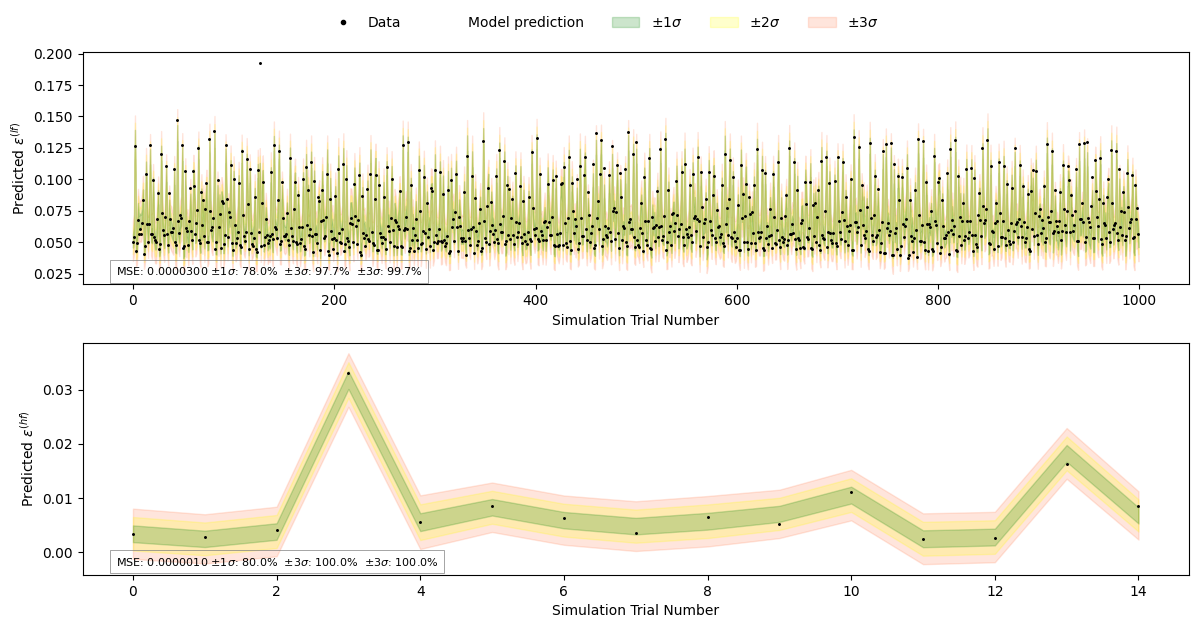

In [20]:
fig = mf_vis.plot_validation(x_train,y_train)
fig

In [21]:
x_test_lf = data.loc[(data['fidelity']==0.) & (data['iteration']==-1)][x_labels].to_numpy()
y_test_lf = (y_scaling*data.loc[(data['fidelity']==0.) & (data['iteration']==-1)][y_label_lf].to_numpy())

x_test_hf = data.loc[(data['fidelity']==1.) & (data['iteration']==-1)][x_labels].to_numpy()
y_test_hf = (y_scaling*data.loc[(data['fidelity']==1.) & (data['iteration']==-1)][y_label_hf].to_numpy())

x_test = [x_test_lf,x_test_hf]
y_test=[y_test_lf,y_test_hf]

In [22]:
fig = mf_vis.plot_validation(x_test,y_test)
fig.savefig(f"{prefix}/validation.png",dpi=300, bbox_inches='tight')

<IPython.core.display.Javascript object>

In [23]:
fig=mf_vis.plot_projection(x_test, y_test,with_prediction=True,grid_steps=20)
fig.savefig(f"{prefix}/projection.png",dpi=300, bbox_inches='tight')

<IPython.core.display.Javascript object>